<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

In [4]:
!pip install -q gdown
!gdown 1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x


Downloading...
From (original): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x
From (redirected): https://drive.google.com/uc?id=1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x&confirm=t&uuid=feab9c82-2634-4dfc-aace-42c295969669
To: /content/archive.zip
100% 4.28G/4.28G [02:07<00:00, 33.5MB/s]
unzip:  cannot find or open faces_dataset_small.zip, faces_dataset_small.zip.zip or faces_dataset_small.zip.ZIP.


In [5]:
!unzip -q archive.zip -d faces_dataset_small

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [7]:
def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

In [8]:
def get_dataloader(image_size, batch_size, root):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  transform = tt.Compose([
      tt.Resize((image_size, image_size)),
      tt.ToTensor(),
      tt.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
  ])
  dataset = ImageFolder(root=root, transform=transform)
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
  return dataloader

In [9]:
image_size = 128
batch_size = 64
root='/content/faces_dataset_small'
dataloader = get_dataloader(image_size, batch_size, root)


In [39]:
def denorm(img_tensors):
    return img_tensors * 0.5 + 0.5

def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach().cpu()[:nmax]), nrow=8).permute(1, 2, 0))

def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

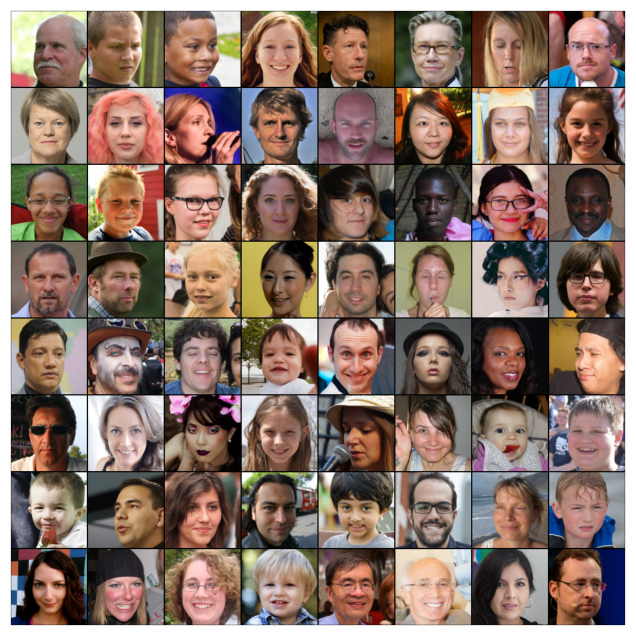

In [11]:
show_batch(dataloader)

In [12]:
xb = torch.randn(batch_size, latent_size, 1, 1)
fake_images = Generator(xb)
print(fake_images.shape)
show_images(fake_images)

NameError: name 'latent_size' is not defined

In [13]:
images, labels = next(iter(dataloader))
print(images.shape)

torch.Size([64, 3, 128, 128])


In [14]:
print (labels)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [15]:
discriminator = nn.Sequential(
            # 3 x 128 x 128
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 x 64 x 64
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 32 x 32
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 256 x 16 x 16
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # 512 x 8 x 8
            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),
            # 1024 x 4 x 4
            nn.Conv2d(1024, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Flatten(),
            nn.Sigmoid()
            # 1 x 1 x 1
        )

In [16]:
latent_size = 128

generator = nn.Sequential(
            # latent_size x 1 x 1
            nn.ConvTranspose2d(latent_size, 1024, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            # 1024 x 4 x 4
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # 512 x 8 x 8
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # 256 x 16 x 16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # 128 x 32 x 32
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # 64 x 64 x 64
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
            # 3 x 128 x 128
        )

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [24]:
def save_samples(index, latent_tensors, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'generated-images-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    print('Saving', fake_fname)
    if show:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1, 2, 0))

In [21]:
def fit(model, criterion, epochs, lr, dataloader ,start_idx=1):
    model["discriminator"].train()
    model["generator"].train()
    torch.cuda.empty_cache()

    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    # Create optimizers
    optimizer = {
        "discriminator": torch.optim.Adam(model["discriminator"].parameters(),
                                          lr=lr, betas=(0.5, 0.999)),
        "generator": torch.optim.Adam(model["generator"].parameters(),
                                      lr=lr, betas=(0.5, 0.999))
    }

    for epoch in range(epochs):
        loss_d_per_epoch = []
        loss_g_per_epoch = []
        real_score_per_epoch = []
        fake_score_per_epoch = []
        for real_images, _ in tqdm(dataloader):
            real_images = real_images.to(device)
            # Train discriminator
            # Clear discriminator gradients
            optimizer["discriminator"].zero_grad()

            # Pass real images through discriminator
            real_preds = model["discriminator"](real_images)
            real_targets = torch.ones(real_images.size(0), 1, device=device)
            real_loss = criterion["discriminator"](real_preds, real_targets)
            cur_real_score = torch.mean(real_preds).item()

            # Generate fake images
            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            # Pass fake images through discriminator
            fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
            fake_preds = model["discriminator"](fake_images)
            fake_loss = criterion["discriminator"](fake_preds, fake_targets)
            cur_fake_score = torch.mean(fake_preds).item()

            real_score_per_epoch.append(cur_real_score)
            fake_score_per_epoch.append(cur_fake_score)

            # Update discriminator weights
            loss_d = real_loss + fake_loss
            loss_d.backward()
            optimizer["discriminator"].step()
            loss_d_per_epoch.append(loss_d.item())


            # Train generator
            # Clear generator gradients
            optimizer["generator"].zero_grad()

            # Generate fake images
            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            # Try to fool the discriminator
            preds = model["discriminator"](fake_images)
            targets = torch.ones(batch_size, 1, device=device)
            loss_g = criterion["generator"](preds, targets)

            # Update generator weights
            loss_g.backward()
            optimizer["generator"].step()
            loss_g_per_epoch.append(loss_g.item())

        # Record losses & scores
        losses_g.append(np.mean(loss_g_per_epoch))
        losses_d.append(np.mean(loss_d_per_epoch))
        real_scores.append(np.mean(real_score_per_epoch))
        fake_scores.append(np.mean(fake_score_per_epoch))

        # Log losses & scores (last batch)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs,
            losses_g[-1], losses_d[-1], real_scores[-1], fake_scores[-1]))

        # Save generated images
        if epoch == epochs - 1:
          save_samples(epoch+start_idx, fixed_latent, show=False)

    return losses_g, losses_d, real_scores, fake_scores

In [18]:
discriminator = to_device(discriminator, device)
generator = to_device(generator, device)

In [27]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

epochs=2

In [29]:
sample_dir = 'generated'
os.makedirs(sample_dir, exist_ok=True)

In [26]:
fixed_latent = torch.randn(64, latent_size, 1, 1, device=device)

In [30]:
history = fit(model, criterion, epochs, lr, dataloader)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch [1/2], loss_g: 3.9994, loss_d: 0.7838, real_score: 0.7485, fake_score: 0.2586


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch [2/2], loss_g: 4.0832, loss_d: 0.7141, real_score: 0.7489, fake_score: 0.2375
Saving generated-images-0002.png


Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

In [32]:
losses_g, losses_d, real_scores, fake_scores = history

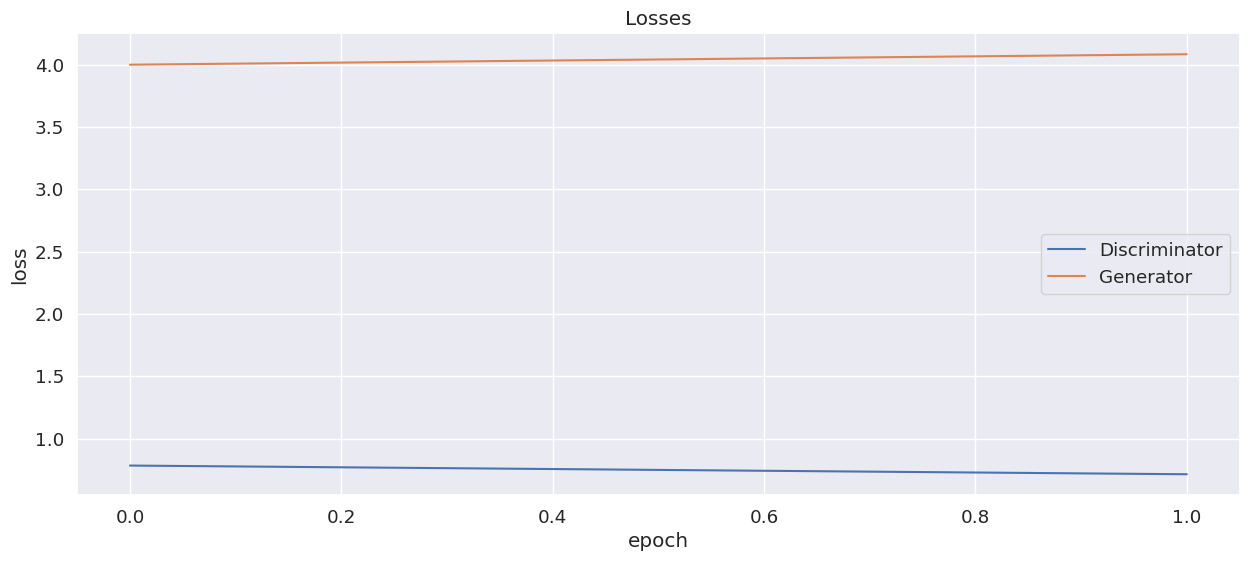

In [33]:
plt.figure(figsize=(15, 6))
plt.plot(losses_d, '-')
plt.plot(losses_g, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [34]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

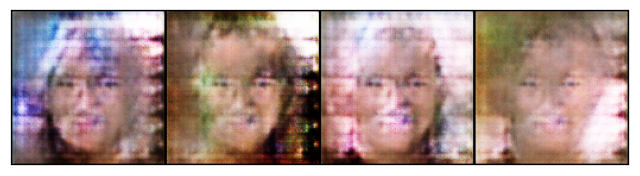

In [40]:
fake_images = model["generator"](fixed_latent)
show_images(fake_images)

Как вам качество получившихся изображений?

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
import numpy as np

def loo_1nn_accuracy(model, dataloader, device):
    model["generator"].eval()

    # собираем реальные изображения
    real_images = []
    for imgs, _ in dataloader:
        real_images.append(imgs)
    real_images = torch.cat(real_images, dim=0)
    n = len(real_images)

    # генерируем столько же фейковых
    with torch.no_grad():
        noise = torch.randn(n, latent_size, 1, 1, device=device)
        fake_images = model["generator"](noise).cpu()

    # flatten: [n, 3, 128, 128] -> [n, 3*128*128]
    real_flat = real_images.view(n, -1).numpy()
    fake_flat = fake_images.view(n, -1).numpy()

    X = np.concatenate([real_flat, fake_flat], axis=0)  # [2n, features]
    y = np.array([1] * n + [0] * n)                     # real=1, fake=0

    # LOO + 1NN
    loo = LeaveOneOut()
    knn = KNeighborsClassifier(n_neighbors=1)

    preds = []
    for train_idx, test_idx in loo.split(X):
        knn.fit(X[train_idx], y[train_idx])
        preds.append(knn.predict(X[test_idx])[0])

    acc = accuracy_score(y, preds)
    print(f"LOO 1-NN accuracy: {acc:.4f}")
    return acc

In [ ]:
acc = loo_1nn_accuracy(model, dataloader, device)
print(acc)

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

Running t-SNE...


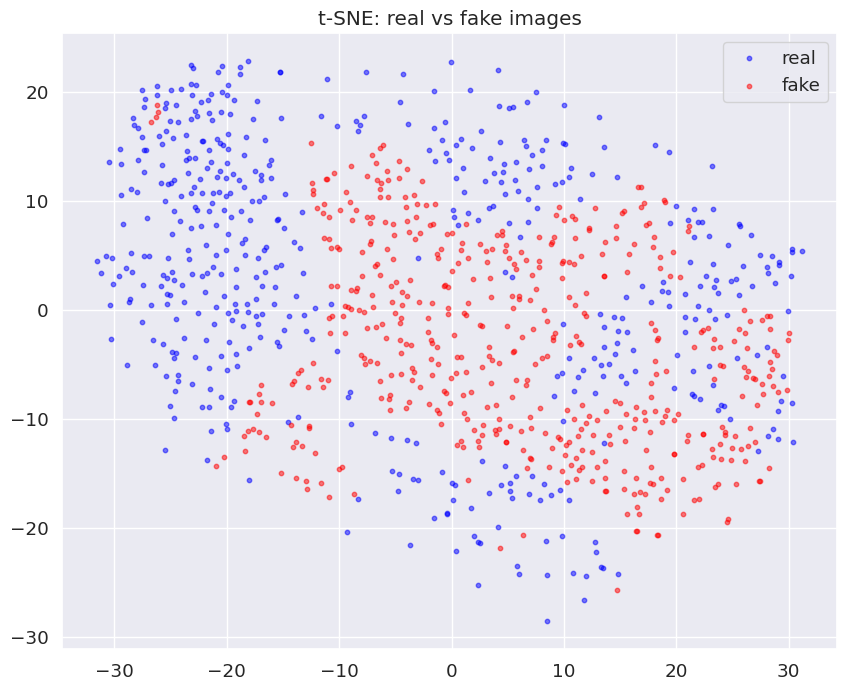

In [35]:
from sklearn.manifold import TSNE

def plot_tsne(model, dataloader, device, n_samples=500):
    model["generator"].eval()

    # реальные изображения
    real_images = []
    for imgs, _ in dataloader:
        real_images.append(imgs)
        if sum(x.shape[0] for x in real_images) >= n_samples:
            break
    real_images = torch.cat(real_images, dim=0)[:n_samples]

    # фейковые
    with torch.no_grad():
        noise = torch.randn(n_samples, latent_size, 1, 1, device=device)
        fake_images = model["generator"](noise).cpu()

    # flatten
    real_flat = real_images.view(n_samples, -1).numpy()
    fake_flat = fake_images.view(n_samples, -1).numpy()

    X = np.concatenate([real_flat, fake_flat], axis=0)
    labels = np.array(['real'] * n_samples + ['fake'] * n_samples)

    # t-SNE
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X)

    # plot
    plt.figure(figsize=(10, 8))
    for label, color in [('real', 'blue'), ('fake', 'red')]:
        mask = labels == label
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.5, s=10)
    plt.legend()
    plt.title("t-SNE: real vs fake images")
    plt.show()

plot_tsne(model, dataloader, device)

Прокомментируйте получившийся результат:

In [ ]:
мне все нравится